<a href="https://colab.research.google.com/github/wjdwogns2873-web/deep-learning-study/blob/main/Kaggle_Study/13_Fruit_Images_for_Object_Detection2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
제미나이의 도움을 받아 작성한 코드입니다.
```



In [1]:
# 1. 구글 드라이브 연결 (로그인 팝업이 뜨면 확인만 눌러주세요)
from google.colab import drive
drive.mount('/content/drive')

# 2. 구글 드라이브에 저장해둔 열쇠(access_token)를 코랩 보안 폴더로 자동 복사
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/Kaggle/access_token ~/.kaggle/
!chmod 600 ~/.kaggle/access_token

Mounted at /content/drive


In [1]:
!kaggle datasets download mbkinaci/fruit-images-for-object-detection

Dataset URL: https://www.kaggle.com/datasets/mbkinaci/fruit-images-for-object-detection
License(s): CC0-1.0
100% 28.4M/28.4M [00:03<00:00, 9.83MB/s]



In [2]:
!unzip -q fruit-images-for-object-detection.zip -d ./data

In [3]:
import os
import zipfile
import shutil

# 1. 경로 정의
ZIP_PATH = './fruit-images-for-object-detection.zip'
EXTRACT_PATH = './fruit_raw'
BASE_DIR = './dataset'

# 기존에 쓰던 임시 폴더가 있다면 Clean 작업 수행
if os.path.exists(EXTRACT_PATH):
    shutil.rmtree(EXTRACT_PATH)
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

# 원본 압축 파일 해제
if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
        print("압축 해제 완료")
else:
    print("파일이 없습니다.")

# 2. 파이토치 표준 학습 폴더 구조 생성
os.makedirs(os.path.join(BASE_DIR, 'train'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'test'), exist_ok=True)

압축 해제 완료


In [4]:
import os
import glob
import torch
from PIL import Image
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset
import torchvision.transforms as T

# 과일 클래스 매핑 정의
# Faster R-CNN은 배경(Background)을 0번으로 고정해야 하므로 1번부터 부여합니다.
class_to_idx = {'apple': 1, 'banana': 2, 'orange': 3}

class FruitObjectDetectionDataset(Dataset):
    def __init__(self, raw_data_dir, transforms=None):
        self.raw_data_dir = raw_data_dir
        self.transforms = transforms

        # 폴더 내 모든 xml 파일 목록을 정렬해서 가져옵니다.
        self.xml_files = sorted(glob.glob(os.path.join(raw_data_dir, '*.xml')))

    def __len__(self):
        return len(self.xml_files)

    def __getitem__(self, idx):
        # 1. 인덱스에 해당하는 xml 정답지 경로 확보
        xml_path = self.xml_files[idx]

        # 2. xml 파싱
        tree = ET.parse(xml_path)
        root = tree.getroot()

        # 3. 정답지와 매핑되는 이미지 파일 로드
        img_name = root.find('filename').text
        img_path = os.path.join(self.raw_data_dir, img_name)
        img = Image.open(img_path).convert('RGB') # PIL 이미지 객체 로드

        # 4. Bounding Box 정보 및 레이블 추출
        boxes, labels = [], []

        # xml 내부의 모든 <object> 태그를 순회 (사과, 바나나가 한 이미지에 여러 개 있을 수 있음)
        for obj in root.iter('object'):
            name = obj.find('name').text
            if name not in class_to_idx:
                continue # 정의되지 않은 클래스는 스킵

            labels.append(class_to_idx[name])

            # 픽셀 절대 좌표 추출 (Pascal VOC 포맷: xmin, ymin, xmax, ymax)
            xmlbox = obj.find('bndbox')
            xmin = float(xmlbox.find('xmin').text)
            ymin = float(xmlbox.find('ymin').text)
            xmax = float(xmlbox.find('xmax').text)
            ymax = float(xmlbox.find('ymax').text)

            boxes.append([xmin, ymin, xmax, ymax])

        # 5. 파이토치 모델이 원하는 데이터 타입(Tensor)으로 캐스팅
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        image_id = torch.tensor([idx])

        # 박스의 면적 계산 (Faster R-CNN 평가 지표 계산시 내부적으로 사용됨)
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # 객체가 몰려있어 가려졌는지 여부 (여기서는 기본값 0)
        iscrowded = torch.zeros((len(labels),), dtype=torch.int64)

        # 파이토치 Faster R-CNN 전용 정답 딕셔너리 구조 생성
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': image_id,
            'area': area,
            'iscrowded': iscrowded
        }

        # 6. 이미지 변형 적용 (이미지를 텐서로 바꾸고 스케일링)
        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

In [5]:
# 단순 이미지 변환용 임시 함수 (PIL -> Tensor 변환만 수행)
def 기본_변환(image, target):
    import torchvision.transforms.functional as F
    return F.to_tensor(image), target

# 데이터셋 객체 생성 (아까 1단계에서 압축 푼 폴더 지정)
test_dataset = FruitObjectDetectionDataset(raw_data_dir='./fruit_raw/train_zip/train', transforms=기본_변환)

# 0번째 데이터 하나 꺼내오기 (JPA의 findById(0) 처럼)
img_tensor, target_dto = test_dataset[0]

print("=== 2단계 데이터셋 유닛 테스트 결과 ===")
print(f"1. 이미지 텐서 Shape: {img_tensor.shape}") # [체널(RGB), 세로, 가로]
print(f"2. 발견된 객체 수: {len(target_dto['labels'])}개")
print(f"3. 네모 박스 좌표들:\n{target_dto['boxes']}")
print(f"4. 매핑된 클래스 ID들: {target_dto['labels']}")

=== 2단계 데이터셋 유닛 테스트 결과 ===
1. 이미지 텐서 Shape: torch.Size([3, 349, 349])
2. 발견된 객체 수: 1개
3. 네모 박스 좌표들:
tensor([[  8.,  15., 331., 349.]])
4. 매핑된 클래스 ID들: tensor([1])


In [6]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_object_detection_model(num_classes):
    # 미리 학습된 Faster R-CNN 모델을 로드하고,
    # 우리 데이터셋의 클래스 개수에 맞게 마지막 예측 레이어(head)를 리팩토링하는 함수
    # 1. COCO 데이터셋으로 선행 학습된 뼈대 모델 로드 (가중치 포함)
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

    # 2. 모델이 원래 가지고 있던 마지막 분류기(Classifier)의 입력 기능(feature) 개수를 파악합니다.
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # 3. 모델의 원래 머리(head)를 떼어내고, 우리 스펙(num_classes)에 맞는 새로운 머리로 교체합니다.
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

# 클래스 수: 배경(0) + 사과(1) + 바나나(2) + 오렌지(3)
NUM_CLASSES = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

# 우리만의 커스텀 모델 객체 생성
my_model = get_object_detection_model(NUM_CLASSES)
my_model.to(device)

device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 201MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [7]:
import torch
from torch.utils.data import DataLoader

# 1. 파이토치 데이터로더가 객체 탐지용 [이미지 리스트, 정답 DTO 리스트]를 예쁘게 묶을 수 있도록
# collate_fn(수집 함수)을 정의해 줍니다.
def collate_fn(batch):
    return tuple(zip(*batch))

# 2. 진짜 학습용(Train)과 검증용(Test) 데이터로더 생성
train_dataset = FruitObjectDetectionDataset(raw_data_dir='./fruit_raw/train_zip/train', transforms=기본_변환)
test_dataset = FruitObjectDetectionDataset(raw_data_dir='./fruit_raw/test_zip/test', transforms=기본_변환)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

# 3. 옵티마이저 설정 - 모델의 뇌(가중치)를 수정하는 알고리즘
params = [p for p in my_model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# 4. 진짜 학습 루프
epochs = 3

for epoch in range(epochs):
    my_model.train()
    epoch_loss = 0

    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = my_model(images, targets)

        # 반환된 여러 Loss(박스 위치 오차, 분류 오차 등)를 하나로 합침
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    print(f"Epoch [{epoch+1}/{epochs}] - Avg Loss: {epoch_loss/len(train_loader):.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/3] - Avg Loss: 0.2988
Epoch [2/3] - Avg Loss: 0.2084
Epoch [3/3] - Avg Loss: 0.1505


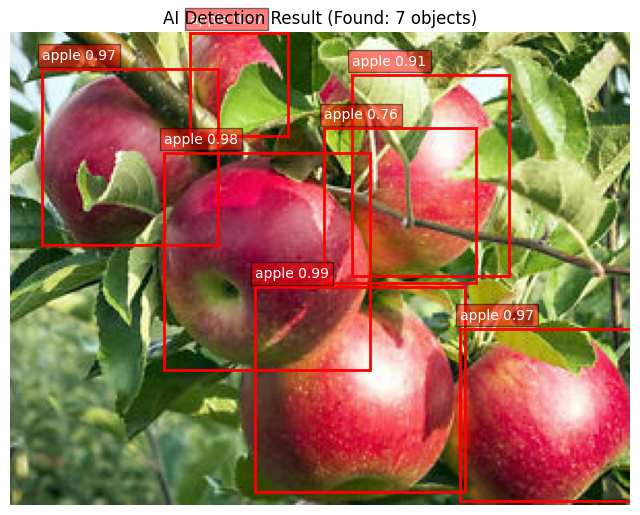

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_prediction(dataset, model, device, index=0):
    # 지정한 인덱스의 테스트 이미지를 모델에 입력하고,
    # 모델이 예측한 네모 박스를 이미지 위에 예쁘게 그려주는 함수입니다.

    model.eval()

    # 데이터셋에서 테스트용 이미지와 정답(Ground Truth) 가져오기
    image, target = dataset[index]

    # 모델 추론 진행
    with torch.no_grad():
        prediction = model([image.to(device)])

    # 시각화를 위해 GPU에 있던 이미지 텐서를 CPU로 가져오고, [C, H, W]를 [H, W, C] 구조로 복원
    np_image = image.permute(1, 2, 0).cpu().numpy()

    # 그리기 준비 (도화지 세팅)
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(np_image)

    # 인공지능이 예측한 결과 추출
    pred_boxes = prediction[0]['boxes'].cpu().numpy()
    pred_labels = prediction[0]['labels'].cpu().numpy()
    pred_scores = prediction[0]['scores'].cpu().numpy()

    # 정답 인덱스를 다시 과일 이름으로 바꾸기 위한 역매핑 맵
    idx_to_class = {1: 'apple', 2: 'banana', 3: 'orange'}

    # 예측한 객체들을 하나씩 순회하며 이미지 위에 네모 상자 그리기
    detected_count = 0
    for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
        # 신뢰도(Confidence Score)가 50% 이상인 박스만 화면에 그리기
        if score > 0.50:
            detected_count += 1
            xmin, ymin, xmax, ymax = box

            # matplotlib의 사각형 패치는 [왼쪽 위 X, 왼쪽 위 Y, 가로길이, 세로길이]를 요구함
            width = xmax - xmin
            height = ymax - ymin

            # 네모 상자 설정
            rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

            # 상자 위에 글자 쓰기 (예: apple 0.87)
            class_name = idx_to_class.get(label, 'unknown')
            plt.text(xmin, ymin - 10, f"{class_name} {score:.2f}", color='white',
                     verticalalignment='top', bbox={'boxstyle': 'square', 'facecolor': 'red', 'alpha': 0.5})

    plt.axis('off')
    plt.title(f"AI Detection Result (Found: {detected_count} objects)")
    plt.show()

# 테스트 데이터셋의 0번 이미지로 인공지능 탐지기 가동
visualize_prediction(test_dataset, my_model, device, index=0)